In [1]:
%load_ext autoreload
%autoreload 2
%reset -f

In [2]:
import sqlite3
import pandas as pd
import numpy as np
import sys
import os 

from locallib.picarrodb import *
from locallib.box import *
from locallib.query import *
from locallib.pandas import *


/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/geopandas/_compat.py:154: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.1-CAPI-1.16.0). Conversions between both will be slow.
  set_use_pygeos()


EU1_Conn created successfully
EU2_Conn created successfully
DataHub_Conn created successfully
US_Conn created successfully


# Configuration Parameters

In [3]:
client = ['Cadent']
sunset_sunrise = [6, 20]
period = 'Week'
standard_utilization = {'Days':5,'Hours':6}
customer_utilization = {'Days':7,'Hours':7, "Surveyors": 25}

# Query data

## Set-up the query

In [4]:
a = get_reports('Cadent',years = [2026],table_name = "#TempReport")
b = query_emission_sources_table(report_table="#TempReport",table_name = "#TempEmissionSource")
c = query_surveys_table(report_table="#TempReport",table_name = "#TempSurvey")
d = query_segments_table(survey_table="#TempSurvey",table_name = "#TempSegment")
e = query_SurveyH3Aggregation(survey_table="#TempSurvey",table_name = "#TempSurveyH3Aggregation")
c.set_child(d)
b.set_child(c)
a.set_child(b)
data = a.execute(EU2_Conn, table_return = ["#TempReport","#TempSurvey","#TempSegment","#TempEmissionSource"])

## Process the data

In [5]:
survey_summary = pd.DataFrame()
emission_summary = pd.DataFrame()
report_summary = pd.DataFrame()

## Prepare summary main tables
#### The summaries are not dependent on date

#### Summary of Report

In [6]:
report_summary = data['#TempReport'].copy()[[
    'ReportId',
    'ReportName',
    'ReportDate',
    'ReportAssetLengthKm', 
    'AssetCoveredLengthKm', 
    'DistributionPipeKm',
    'DistributionPipeCoveredKm', 
    'DistributionPipePercentCovered', 
    'ServicePipeKm', 
    'ServicePipeCoveredKm',

]]
# Clisify (classify) the report_summary by different periods using to_period: quarter, year, month, week
#report_summary['ReportQuarter'] = pd.to_datetime(report_summary['ReportDate']).dt.isocalendar().quarter
report_summary['ReportYear'] = pd.to_datetime(report_summary['ReportDate']).dt.year
report_summary['ReportMonth'] = pd.to_datetime(report_summary['ReportDate']).dt.month
report_summary['ReportWeek'] = pd.to_datetime(report_summary['ReportDate']).dt.isocalendar().week

#### Summary of EmissionSource

In [7]:
def summarize_emission(group):
    # Remove all the rows in the group where Disposition == 2
    forCounts = group[group["Disposition"] != 2]
    forShares = group
    return pd.Series({
        "EmissionRate": forCounts["EmissionRate"].sum(),
        "LisaCount": forCounts["EmissionSourceId"].count(),
        "B0Count": forCounts["RepresentativeBinLabel"].value_counts().get("B0"),
        "B1Count": forCounts["RepresentativeBinLabel"].value_counts().get("B1"),
        "Bm1Count": forCounts["RepresentativeBinLabel"].value_counts().get("B-1"),
        "Bm2Count": forCounts["RepresentativeBinLabel"].value_counts().get("B-2"),
        "Not_NGCount": forShares["Disposition"].value_counts().get(2),
        "PGCount": forShares["Disposition"].value_counts().get(3),
        "NGCount": forShares["Disposition"].value_counts().get(1),
    })

emissions_summary = data['#TempEmissionSource'].groupby("ReportId").apply(summarize_emission)
emissions_summary.fillna(0)

,EmissionRate,LisaCount,B0Count,B1Count,Bm1Count,Bm2Count,Not_NGCount,PGCount,NGCount
ReportId,,,,,,,,,
005BC512-DA5E-6604-BCFE-3A1F6364ABEF,34.592136,36.0,9.0,0.0,25.0,2.0,1.0,7.0,29.0
007A1657-3664-172E-C2F8-3A1FCF4E6563,25.674252,50.0,7.0,0.0,38.0,5.0,27.0,6.0,44.0
007E3C3E-F141-BB09-C7D3-3A208DA42F11,22.102866,18.0,9.0,0.0,8.0,1.0,4.0,4.0,14.0
0085BBDA-DA52-9FFA-5413-3A20EA508DA6,9.502055,12.0,1.0,0.0,9.0,2.0,1.0,2.0,10.0
0113A253-CDB2-E52C-9A46-3A1F58DB2A93,50.674148,58.0,17.0,0.0,39.0,2.0,1.0,4.0,54.0
...,...,...,...,...,...,...,...,...,...
FEFA8672-5284-BAF7-4EC3-3A20AC89A339,27.290299,34.0,10.0,0.0,23.0,1.0,1.0,2.0,32.0
FF12F270-23B0-C895-2A06-3A20DACD4363,64.945722,103.0,17.0,0.0,74.0,12.0,3.0,11.0,92.0
FF34A77E-2448-D1CE-7EF3-3A1FA0DE91D2,21.796171,25.0,9.0,0.0,13.0,3.0,2.0,5.0,20.0


#### Summary of Survey

In [8]:
sunrise = 6
sunset = 20
speed_threshold = 0.5

# Define a function to determine if survey is in 'day' or 'night'
def get_day_night(start_time, sunrise, sunset):
    # start_time should be a datetime.time object
    hour = start_time.hour
    if sunrise <= hour < sunset:
        return 'Day'
    else:
        return 'Night'

def set_actie_idle(speed, speed_threshold):
    if speed < speed_threshold:
        return 'Idle'
    else:
        return 'Active'


# Convert StartEpoch to datetime (time only, no date)
data['#TempSegment']['StartTime'] = pd.to_datetime(data['#TempSegment']['StartEpoch'], unit='s').dt.time
data['#TempSegment']['StartDate'] = pd.to_datetime(data['#TempSegment']['StartEpoch'], unit='s')
data['#TempSegment']['DayNight'] = data['#TempSegment']['StartTime'].apply(lambda t: get_day_night(t, sunrise, sunset))
data['#TempSegment']['ActiveIdle'] = data['#TempSegment']['CarSpeedMedian'].apply(lambda x: set_actie_idle(x, speed_threshold))

# Set the starting time as a datetime object
data['#TempSurvey']['StartHour'] = pd.to_datetime(data['#TempSurvey']['StartEpoch'], unit='s').dt.hour
data['#TempSurvey']['StartTime'] = pd.to_datetime(data['#TempSurvey']['StartEpoch'], unit='s').dt.time
data['#TempSurvey']['EndHour'] = pd.to_datetime(data['#TempSurvey']['EndEpoch'], unit='s').dt.hour
data['#TempSurvey']['EndTime'] = pd.to_datetime(data['#TempSurvey']['EndEpoch'], unit='s').dt.time
data['#TempSurvey']['StartDay'] = pd.to_datetime(data['#TempSurvey']['StartEpoch'], unit='s').dt.date
data['#TempSurvey']['EndDay'] = pd.to_datetime(data['#TempSurvey']['EndEpoch'], unit='s').dt.date

# Calculate the duration (in minutes) between StartEpoch and EndEpoch for each survey
data['#TempSurvey']['DurationMinutes'] = (
    data['#TempSurvey']['EndEpoch'] - data['#TempSurvey']['StartEpoch']
) / 60

def segment_summary_apply(df):
    return pd.Series({
        'DaySegments': (df['DayNight'] == 'Day').sum(),
        'NightSegments': (df['DayNight'] == 'Night').sum(),
        'ActiveSegments': (df['ActiveIdle'] == 'Active').sum(),
        'IdleSegments': (df['ActiveIdle'] == 'Idle').sum(),
        'TotalSegments': len(df),
        'TotalKilometers': df['LengthMeters'].sum() / 1000,
        'DayKilometers': df.loc[df['DayNight'] == 'Day', 'LengthMeters'].sum() / 1000,
        'NightKilometers': df.loc[df['DayNight'] == 'Night', 'LengthMeters'].sum() / 1000,
        'SegmentDurationMinutes': df['DurationSeconds'].sum() / 60,
        'IdleTimeMinutes': df.loc[df['ActiveIdle'] == 'Idle', 'DurationSeconds'].sum() / 60,
        'ActiveTimeMinutes': df.loc[df['ActiveIdle'] == 'Active', 'DurationSeconds'].sum() / 60,
        'AvgSpeedKm': 3.6*df['CarSpeedMedian'].mean()

    })

def survey_summary_apply(row):
    return pd.Series({
        'SurveyId': row['SurveyId'],
        'SurveyorUnit': row['SurveyorUnit'],
        'SurveyDurationMinutes': row['DurationMinutes'],
        'ReportId': row['ReportId'],
        'StartHour': row['StartHour'],
        'StartTime': row['StartTime'],
        'StartEpoch': row['StartEpoch'],
        'EndTime': row['EndTime'],
        'EndEpoch': row['EndEpoch'],
        'StartDay': row['StartDay'],
        'EndDay': row['EndDay'],
        'LateralRotation': row['LateralRotation'],
        'NumberOfPeaks': row['NumberOfPeaks']
    })

# Apply the function row-wise (axis=1) to build a DataFrame summary
survey_summary = data['#TempSurvey'].apply(survey_summary_apply, axis=1)
segment_summary = data['#TempSegment'].groupby("SurveyId").apply(segment_summary_apply)
survey_summary = pd.merge(survey_summary,segment_summary,on="SurveyId",how="left")

## Calculate KPI
#### KPI are dependent on time

#### Distribution of survey duration
##### Compute

In [9]:
report_summary_agg = pd.merge(report_summary,survey_summary,on='ReportId',how="left")
aggregator = ['ReportYear','ReportWeek']
# Categorize the surveys by 'night date'

# We'll define a 'night date' as the date the survey starts if it starts before noon;
# otherwise, the 'night date' is the next calendar day. This is sometimes used to attribute
# overnight surveys to the nocturnal period in which most of the survey was conducted.
# Adjust as needed for your definition of "night".

def setAnalysisDate(row):
    if (row['StartHour'] >= 0) & (row['StartHour'] <= 7):
        return (row['StartDay'] - pd.Timedelta(days=1))
    else:
       return row['StartDay']

# Ensure 'StartDay' is in datetime format before using .dt accessor
shift_calc = report_summary_agg.copy()
if not np.issubdtype(shift_calc['StartDay'].dtype, np.datetime64):
    shift_calc['StartDay'] = pd.to_datetime(shift_calc['StartDay'], errors='coerce')

shift_calc = shift_calc[shift_calc['StartDay'].dt.year == 2026].copy()
shift_calc["AnalysisDate"] = shift_calc.apply(setAnalysisDate, axis=1)
# Get the earliest StartTime for each (AnalysisDate, SurveyorUnit) group
time_boundary = shift_calc.groupby(["AnalysisDate", "SurveyorUnit"]).agg({"StartEpoch": "min", "EndEpoch": "max"})

# Assign AnalysisDate to a week (e.g., using pandas Period or custom logic)
# We'll make a new column "AnalysisWeek" for each (AnalysisDate, SurveyorUnit)
time_boundary = time_boundary.reset_index()
time_boundary['Week'] = pd.to_datetime(time_boundary['AnalysisDate']).dt.isocalendar().week
# Convert StartEpoch and EndEpoch to 'HH:MM' format (string)
time_boundary['StartHour'] = pd.to_datetime(time_boundary['StartEpoch'], unit='s').dt.hour
time_boundary['EndHour'] = pd.to_datetime(time_boundary['EndEpoch'], unit='s').dt.hour
time_boundary.reset_index(drop=True)

# Define windows for categorization
good_staring_window = [19, 21]  # 18:00 to 21:59
good_ending_window = [3, 6]     # 03:00 to 05:59

# Categorize each entry in time_boundary based on the windows but output as 2 columns (GoodStart, GoodEnd)
def get_good_start(row):
    return True if good_staring_window[0] <= row['StartHour'] <= good_staring_window[1] else False

def get_good_end(row):
    return True if good_ending_window[0] <= row['EndHour'] <= good_ending_window[1] else False

time_boundary['GoodStart'] = time_boundary.apply(get_good_start, axis=1)
time_boundary['GoodEnd'] = time_boundary.apply(get_good_end, axis=1)
time_boundary['Week'] = pd.to_datetime(time_boundary['AnalysisDate']).dt.isocalendar().week
time_boundary

,AnalysisDate,SurveyorUnit,StartEpoch,EndEpoch,Week,StartHour,EndHour,GoodStart,GoodEnd
0,2026-01-04,Cadent Surveyor #01 - LO75ZDT,1.767561e+09,1.767579e+09,1,21,2,True,False
1,2026-01-05,Cadent Surveyor #01 - LO75ZDT,1.767652e+09,1.767665e+09,2,22,2,False,False
2,2026-01-05,Cadent Surveyor #02 - LO75TNZ,1.767646e+09,1.767661e+09,2,20,0,True,False
3,2026-01-05,Cadent Surveyor #03 - LO75GFG,1.767645e+09,1.767665e+09,2,20,2,True,False
4,2026-01-06,Cadent Surveyor #01 - LO75ZDT,1.767732e+09,1.767751e+09,2,20,2,True,False
...,...,...,...,...,...,...,...,...,...
1689,2026-05-11,Cadent Surveyor #15 - LO75TKU,1.778530e+09,1.778553e+09,20,20,2,True,False
1690,2026-05-11,Cadent Surveyor #17 - LO75XCZ,1.778533e+09,1.778545e+09,20,20,0,True,False
1691,2026-05-11,Cadent Surveyor #18 - LP75GDE,1.778532e+09,1.778542e+09,20,20,23,True,False
1692,2026-05-11,Cadent Surveyor #19 - LO75VJN,1.778531e+09,1.778551e+09,20,20,2,True,False


In [10]:
time_boundary[time_boundary['Week'] == 14]

,AnalysisDate,SurveyorUnit,StartEpoch,EndEpoch,Week,StartHour,EndHour,GoodStart,GoodEnd
878,2026-03-30,Cadent Surveyor #01 - LO75ZDT,1.774905e+09,1.774932e+09,14,21,4,True,True
879,2026-03-30,Cadent Surveyor #02 - LO75TNZ,1.774903e+09,1.774934e+09,14,20,5,True,True
880,2026-03-30,Cadent Surveyor #03 - LO75GFG,1.774903e+09,1.774932e+09,14,20,4,True,True
881,2026-03-30,Cadent Surveyor #04 - LP75BYT,1.774904e+09,1.774930e+09,14,20,4,True,True
882,2026-03-30,Cadent Surveyor #05 - LM75XGO,1.774905e+09,1.774925e+09,14,21,2,True,False
...,...,...,...,...,...,...,...,...,...
944,2026-04-01,Cadent Surveyor #21 - LO75WUV,1.775071e+09,1.775100e+09,14,19,3,True,True
945,2026-04-01,Cadent Surveyor #22 - LP75ODE,1.775077e+09,1.775104e+09,14,20,4,True,True
946,2026-04-01,Cadent Surveyor #23 - LM75YJF,1.775075e+09,1.775104e+09,14,20,4,True,True
947,2026-04-01,Cadent Surveyor #24 - LO75ZKP,1.775074e+09,1.775104e+09,14,20,4,True,True


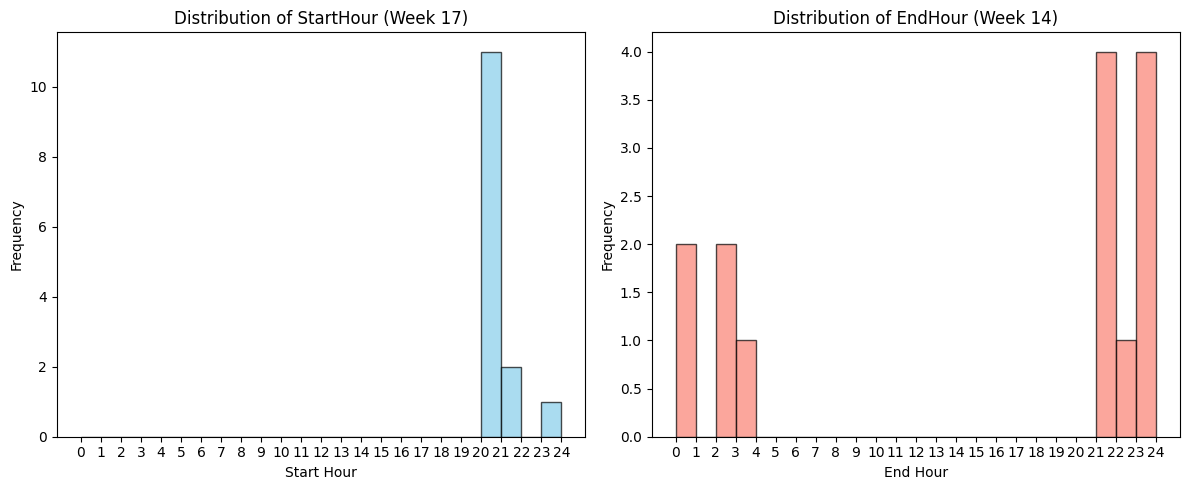

In [11]:
import matplotlib.pyplot as plt
# Plot distribution of StartHour and EndHour for week 17
week_17_data = time_boundary[time_boundary['Week'] == 20]

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(week_17_data['StartHour'].dropna(), bins=range(0,25), alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Start Hour')
plt.ylabel('Frequency')
plt.title('Distribution of StartHour (Week 17)')
plt.xticks(range(0, 25))

plt.subplot(1,2,2)
plt.hist(week_17_data['EndHour'].dropna(), bins=range(0,25), alpha=0.7, color='salmon', edgecolor='black')
plt.xlabel('End Hour')
plt.ylabel('Frequency')
plt.title('Distribution of EndHour (Week 14)')
plt.xticks(range(0, 25))

plt.tight_layout()
plt.show()

/tmp/ipykernel_26618/4095225250.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.figure.show()


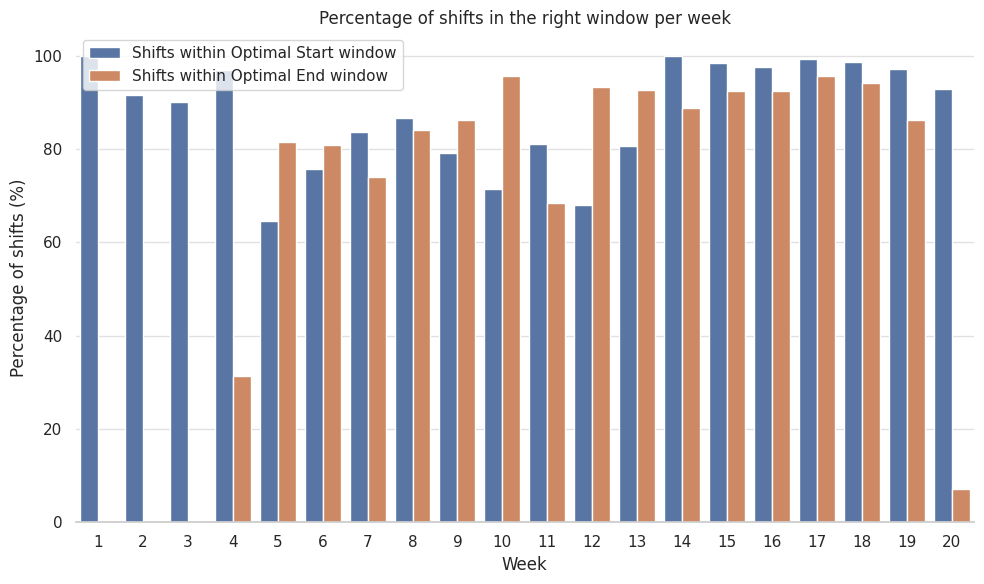

In [12]:
import seaborn as sns

total_starts = time_boundary.groupby('Week').size()

# Sum the number of GoodStart per week
good_start_counts = (time_boundary.groupby('Week')['GoodStart'].sum()) / total_starts
good_end_counts = (time_boundary.groupby('Week')['GoodEnd'].sum()) / total_starts

# Combine into DataFrame (percentage, so *100)
counts_df = pd.DataFrame({
    'Shifts within Optimal Start window': good_start_counts * 100,
    'Shifts within Optimal End window': good_end_counts * 100
}).fillna(0)

# Reshape (melt) for seaborn barplot
counts_df_reset = counts_df.reset_index().melt(id_vars='Week', var_name='Shift', value_name='Percentage')

# Seaborn barplot for percentage of shifts in good windows, by week
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=counts_df_reset, x='Week', y='Percentage', hue='Shift')
ax.set_xlabel('Week')
ax.set_ylabel('Percentage of shifts (%)')
ax.set_title('Percentage of shifts in the right window per week')
ax.legend(title='')
sns.despine(left=True)
ax.grid(axis='y', alpha=0.6)
ax.figure.set_size_inches(10, 6)
ax.figure.tight_layout()
# Show the plot
ax.figure.show()


In [13]:
good_end_counts

Week
1     0.000000
2     0.000000
3     0.000000
4     0.312500
5     0.815789
6     0.807692
7     0.739726
8     0.840000
9     0.861111
10    0.957143
11    0.684211
12    0.932836
13    0.926667
14    0.887324
15    0.924812
16    0.924528
17    0.955414
18    0.942029
19    0.861111
20    0.071429
dtype: float64